<a href="https://colab.research.google.com/github/muajnstu/Large_Scale_Implementation_of_DSK_Chain/blob/main/Visualization_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import friedmanchisquare, rankdata
from itertools import combinations
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch

Relative Performance Index (RPI)

In [2]:
raw = {
    "D1": {
        "ET":       [0.8507,0.9125,0.8504,0.9878, 0.8070,0.8858,0.8063,0.9781, 0.9117,0.9355,0.8963,0.9937, 0.8130,0.8895,0.8123,0.9791],
        "DT":       [0.8052,0.8847,0.8048,0.8887, 0.7401,0.8441,0.7402,0.8515, 0.8983,0.9314,0.8809,0.9329, 0.7461,0.8480,0.7461,0.8549],
        "NB":       [0.6979,0.8171,0.6912,0.9521, 0.7158,0.8287,0.7115,0.9535, 0.8772,0.9116,0.8538,0.9825, 0.7250,0.8346,0.7223,0.9559],
        "LDA":      [0.7331,0.8397,0.7291,0.9619, 0.7425,0.8457,0.7402,0.9622, 0.8887,0.9140,0.8553,0.9902, 0.7556,0.8539,0.7536,0.9649],
        "Voting":   [0.8617,0.9191,0.8614,0.9876, 0.8191,0.8932,0.8185,0.9812, 0.9367,0.9511,0.9256,0.9957, 0.8236,0.8960,0.8229,0.9821],
        "Stacking": [0.8514,0.9129,0.8515,0.9877, 0.8031,0.8835,0.8028,0.9782, 0.9136,0.9416,0.9022,0.9875, 0.8063,0.8854,0.8059,0.9793],
    },
    "D2": {
        "ET":       [0.8415,0.9113,0.8398,0.9841, 0.8415,0.9113,0.8364,0.9833, 0.9541,0.9663,0.9447,0.9986, 0.8415,0.9113,0.8329,0.9828],
        "DT":       [0.8228,0.9004,0.8197,0.9040, 0.7762,0.8728,0.7752,0.8788, 0.9187,0.9278,0.8749,0.9299, 0.7716,0.8700,0.7652,0.8763],
        "NB":       [0.7319,0.8459,0.7230,0.9667, 0.7483,0.8559,0.7440,0.9724, 0.8163,0.8703,0.7416,0.9855, 0.7436,0.8531,0.7334,0.9682],
        "LDA":      [0.6107,0.7687,0.6028,0.9499, 0.6643,0.8036,0.6577,0.9557, 0.7385,0.8325,0.7197,0.9749, 0.6340,0.7840,0.6271,0.9480],
        "Voting":   [0.8695,0.9274,0.8657,0.9876, 0.8601,0.9220,0.8559,0.9851, 0.9753,0.9827,0.9720,0.9989, 0.8462,0.9140,0.8382,0.9846],
        "Stacking": [0.8298,0.9045,0.8287,0.9815, 0.8462,0.9140,0.8422,0.9770, 0.9611,0.9696,0.9495,0.9956, 0.8322,0.9058,0.8230,0.9808],
    },
    "D3": {
        "ET":       [0.9257,0.9581,0.9248,0.9895, 0.8640,0.9225,0.8636,0.9749, 0.9586,0.9740,0.9547,0.9989, 0.8679,0.9247,0.8676,0.9753],
        "DT":       [0.8994,0.9430,0.8976,0.9608, 0.8098,0.8904,0.8097,0.9019, 0.8821,0.9286,0.8735,0.9304, 0.8256,0.8998,0.8255,0.9112],
        "NB":       [0.5328,0.7107,0.5329,0.9343, 0.5403,0.7160,0.5351,0.9345, 0.5931,0.7326,0.5620,0.9396, 0.4924,0.6816,0.4710,0.9207],
        "LDA":      [0.5584,0.7287,0.5554,0.9469, 0.5531,0.7250,0.5504,0.9465, 0.6282,0.7526,0.5856,0.9539, 0.5539,0.7256,0.5516,0.9447],
        "Voting":   [0.9093,0.9487,0.9079,0.9961, 0.8838,0.9340,0.8836,0.9934, 0.9567,0.9734,0.9540,0.9990, 0.8953,0.9407,0.8952,0.9938],
        "Stacking": [0.9519,0.9731,0.9518,0.9968, 0.8870,0.9359,0.8871,0.9936, 0.9676,0.9807,0.9651,0.9993, 0.8944,0.9401,0.8945,0.9940],
    },
    "D4": {
        "ET":       [0.8620,0.9231,0.8600,0.9885, 0.8431,0.9094,0.8357,0.9849, 0.9326,0.9462,0.9093,0.9965, 0.8246,0.9014,0.8204,0.9831],
        "DT":       [0.8402,0.9105,0.8401,0.9151, 0.8089,0.8895,0.8043,0.8951, 0.9222,0.9420,0.8911,0.9433, 0.7856,0.8784,0.7857,0.8847],
        "NB":       [0.4378,0.6460,0.4325,0.9171, 0.4215,0.6309,0.4074,0.9177, 0.4477,0.6454,0.4147,0.9171, 0.3960,0.6133,0.3781,0.9083],
        "LDA":      [0.6007,0.7620,0.5950,0.9538, 0.6285,0.7787,0.6191,0.9563, 0.7110,0.8033,0.6618,0.9691, 0.5879,0.7535,0.5815,0.9501],
        "Voting":   [0.8837,0.9355,0.8801,0.9932, 0.8667,0.9227,0.8567,0.9917, 0.9557,0.9609,0.9340,0.9980, 0.8500,0.9162,0.8427,0.9902],
        "Stacking": [0.8828,0.9350,0.8805,0.9934, 0.8687,0.9242,0.8605,0.9912, 0.9514,0.9609,0.9304,0.9976, 0.8507,0.9166,0.8455,0.9899],
    },
    "D5": {
        "ET":       [0.9807,0.9889,0.9805,0.9995, 0.8388,0.9052,0.8383,0.9861, 0.8790,0.8682,0.7811,0.9896, 0.8760,0.9276,0.8757,0.9899],
        "DT":       [0.9249,0.9565,0.9229,0.9571, 0.7528,0.8522,0.7521,0.8587, 0.8346,0.8575,0.7559,0.8647, 0.7929,0.8772,0.7916,0.8816],
        "NB":       [0.3268,0.5435,0.2669,0.7911, 0.3542,0.5670,0.2974,0.8135, 0.4979,0.5788,0.3552,0.8665, 0.3712,0.5812,0.3307,0.8145],
        "LDA":      [0.5358,0.7073,0.5353,0.9308, 0.6150,0.7623,0.6113,0.9444, 0.6878,0.7409,0.5768,0.9466, 0.6417,0.7803,0.6387,0.9499],
        "Voting":   [0.9740,0.9851,0.9737,0.9994, 0.8560,0.9156,0.8557,0.9879, 0.9052,0.8966,0.8400,0.9940, 0.8852,0.9331,0.8849,0.9907],
        "Stacking": [0.9843,0.9910,0.9843,0.9995, 0.8496,0.9118,0.8497,0.9868, 0.8881,0.9000,0.8293,0.9888, 0.8831,0.9319,0.8835,0.9903],
    },
    "D6": {
        "ET":       [0.9637,0.9772,0.9636,0.9967, 0.9113,0.9440,0.9111,0.9893, 0.9368,0.9457,0.9174,0.9947, 0.9102,0.9433,0.9099,0.9891],
        "DT":       [0.9184,0.9485,0.9175,0.9490, 0.8258,0.8887,0.8255,0.8911, 0.8796,0.9102,0.8549,0.9121, 0.8386,0.8971,0.8382,0.8991],
        "NB":       [0.6231,0.7511,0.5967,0.8881, 0.6580,0.7756,0.6421,0.8963, 0.7277,0.8262,0.7068,0.9333, 0.6594,0.7766,0.6368,0.8991],
        "LDA":      [0.6933,0.8000,0.6908,0.9152, 0.7007,0.8051,0.7002,0.9236, 0.8092,0.8491,0.7568,0.9487, 0.7193,0.8177,0.7181,0.9277],
        "Voting":   [0.9519,0.9698,0.9519,0.9982, 0.9173,0.9478,0.9172,0.9922, 0.9396,0.9488,0.9222,0.9956, 0.9255,0.9530,0.9255,0.9923],
        "Stacking": [0.9857,0.9911,0.9858,0.9980, 0.9216,0.9505,0.9213,0.9924, 0.9492,0.9621,0.9375,0.9960, 0.9323,0.9573,0.9324,0.9916],
    },
    "D7": {
        "ET":       [0.9648,0.9797,0.9644,0.9984, 0.9402,0.9655,0.9393,0.9963, 0.9480,0.9681,0.9446,0.9968, 0.9511,0.9718,0.9509,0.9963],
        "DT":       [0.9716,0.9837,0.9715,0.9838, 0.9169,0.9518,0.9168,0.9525, 0.9300,0.9582,0.9281,0.9587, 0.9417,0.9664,0.9417,0.9667],
        "NB":       [0.6535,0.7881,0.6484,0.9505, 0.7409,0.8447,0.7405,0.9667, 0.7694,0.8590,0.7638,0.9709, 0.7332,0.8398,0.7293,0.9613],
        "LDA":      [0.4543,0.6472,0.4531,0.8553, 0.4768,0.6642,0.4720,0.8651, 0.4958,0.6691,0.4762,0.8711, 0.6030,0.7542,0.5886,0.9148],
        "Voting":   [0.9867,0.9924,0.9867,0.9999, 0.9558,0.9745,0.9556,0.9985, 0.9657,0.9795,0.9649,0.9989, 0.9758,0.9861,0.9758,0.9985],
        "Stacking": [0.9955,0.9974,0.9955,0.9999, 0.9689,0.9821,0.9689,0.9991, 0.9708,0.9829,0.9699,0.9986, 0.9773,0.9870,0.9773,0.9986],
    },
    "D8": {
        "ET":       [0.9776,0.9865,0.9771,0.9996, 0.8860,0.9304,0.8779,0.9864, 0.9570,0.9369,0.8942,0.9956, 0.9178,0.9500,0.9102,0.9929],
        "DT":       [0.9514,0.9706,0.9485,0.9708, 0.8617,0.9153,0.8609,0.9169, 0.9332,0.9318,0.8831,0.9334, 0.8766,0.9247,0.8729,0.9260],
        "NB":       [0.7215,0.8251,0.6998,0.9266, 0.7589,0.8496,0.7419,0.9234, 0.8854,0.8872,0.8129,0.9748, 0.7645,0.8534,0.7429,0.9353],
        "LDA":      [0.4766,0.6535,0.4809,0.8221, 0.4673,0.6462,0.4677,0.8220, 0.5179,0.6533,0.4841,0.8462, 0.5327,0.6950,0.5358,0.8360],
        "Voting":   [0.9607,0.9763,0.9589,0.9997, 0.9084,0.9442,0.9053,0.9891, 0.9761,0.9590,0.9405,0.9966, 0.9308,0.9580,0.9269,0.9949],
        "Stacking": [0.9925,0.9955,0.9925,1.0000, 0.8953,0.9362,0.8951,0.9748, 0.9690,0.9637,0.9374,0.9966, 0.9234,0.9535,0.9221,0.9905],
    },
    "D9": {
        "ET":       [0.9797,0.9865,0.9795,0.9945, 0.9527,0.9683,0.9529,0.9897, 0.9697,0.9747,0.9674,0.9991, 0.9595,0.9729,0.9595,0.9907],
        "DT":       [0.9459,0.9638,0.9451,0.9640, 0.9459,0.9638,0.9459,0.9640, 0.9293,0.9442,0.9148,0.9448, 0.9257,0.9501,0.9264,0.9505],
        "NB":       [0.8243,0.8809,0.8184,0.9456, 0.9122,0.9410,0.9119,0.9878, 0.9697,0.9803,0.9663,0.9950, 0.9257,0.9501,0.9259,0.9937],
        "LDA":      [0.9189,0.9456,0.9196,0.9910, 0.9257,0.9501,0.9257,0.9887, 0.9394,0.9604,0.9362,0.9848, 0.9189,0.9456,0.9185,0.9920],
        "Voting":   [0.9797,0.9865,0.9795,0.9974, 0.9595,0.9729,0.9595,0.9952, 0.9697,0.9747,0.9674,0.9997, 0.9595,0.9729,0.9595,0.9958],
        "Stacking": [0.9797,0.9865,0.9796,0.9928, 0.9459,0.9638,0.9458,0.9844, 0.9798,0.9831,0.9780,0.9801, 0.9257,0.9501,0.9258,0.9687],
    },
    "D10": {
        "ET":       [0.9756,0.9865,0.9756,0.9999, 0.9292,0.9606,0.9290,0.9982, 0.9672,0.9376,0.9198,0.9974, 0.9394,0.9663,0.9392,0.9988],
        "DT":       [0.9704,0.9836,0.9703,0.9837, 0.9187,0.9546,0.9187,0.9553, 0.9667,0.9521,0.9229,0.9531, 0.9336,0.9630,0.9335,0.9635],
        "NB":       [0.3922,0.6069,0.3774,0.8254, 0.3818,0.5985,0.3571,0.8178, 0.5539,0.5864,0.3695,0.9125, 0.3669,0.5862,0.3508,0.8211],
        "LDA":      [0.8331,0.9051,0.8203,0.9936, 0.5250,0.7072,0.5019,0.9054, 0.9461,0.8947,0.8568,0.9964, 0.8352,0.9064,0.8230,0.9944],
        "Voting":   [0.9697,0.9832,0.9695,0.9997, 0.9437,0.9687,0.9435,0.9987, 0.9765,0.9530,0.9411,0.9992, 0.9493,0.9718,0.9491,0.9991],
        "Stacking": [0.9883,0.9936,0.9883,0.9998, 0.9341,0.9633,0.9338,0.9983, 0.9728,0.9553,0.9337,0.9982, 0.9516,0.9731,0.9516,0.9990],
    },
}


datasets   = ["D1","D2","D3","D4","D5","D6","D7","D8","D9","D10"]
models     = ["ET","DT","NB","LDA","Voting","Stacking"]
methods    = ["ROS","SMOTE","SMOTE-NN","BL-SMOTE"]
metrics    = ["Accuracy","G-Mean","F1 Score","AUROC"]
metric_idx = {"Accuracy": 0, "G-Mean": 1, "F1 Score": 2, "AUROC": 3}
d          = len(datasets)


avg = {}
for ds in datasets:
    avg[ds] = {}
    for model in models:
        avg[ds][model] = {}
        for metric, k in metric_idx.items():
            # position k inside each method block of size 4
            vals = [raw[ds][model][j * 4 + k] for j in range(len(methods))]
            avg[ds][model][metric] = np.mean(vals)



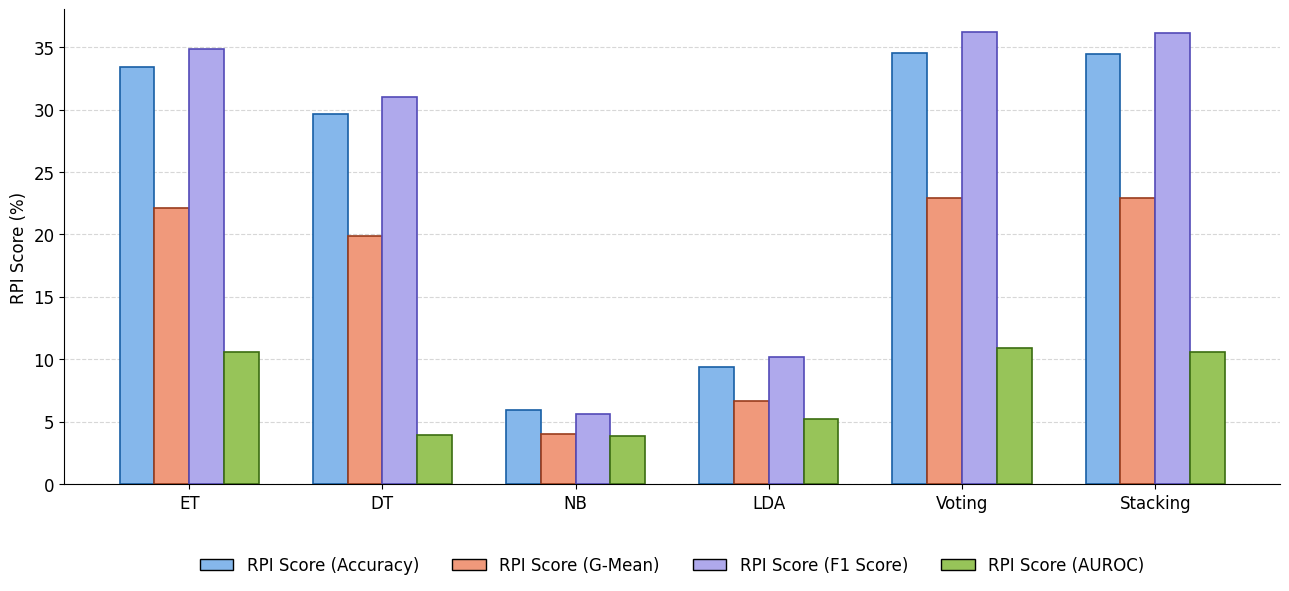

Done. Figure saved as rpi_scores.png


In [3]:
# Compute RPI for each (model, metric) across datasets
# RPI(model, metric) = Σ_i [ (a_i - a_i*) / d ] * 100

rpi = {model: {metric: 0.0 for metric in metrics} for model in models}

for metric in metrics:
    for ds in datasets:
        a_min = min(avg[ds][model][metric] for model in models)
        for model in models:
            rpi[model][metric] += (avg[ds][model][metric] - a_min) / d

for model in models:
    for metric in metrics:
        rpi[model][metric] *= 100


bar_width = 0.18
x         = np.arange(len(models))
n_metrics = len(metrics)
offsets   = np.linspace(-(n_metrics - 1) / 2,
                         (n_metrics - 1) / 2,
                         n_metrics) * bar_width

style = {
    "Accuracy": dict(color="#85B7EB", hatch="", edgecolor="#185FA5", linewidth=1.2),
    "G-Mean":   dict(color="#F0997B", hatch="", edgecolor="#993C1D", linewidth=1.2),
    "F1 Score": dict(color="#AFA9EC", hatch="", edgecolor="#534AB7", linewidth=1.2),
    "AUROC":    dict(color="#97C459", hatch="", edgecolor="#3B6D11", linewidth=1.2),
}

fig, ax = plt.subplots(figsize=(13, 6))

for j, metric in enumerate(metrics):
    vals = [rpi[model][metric] for model in models]
    ax.bar(
        x + offsets[j], vals,
        width=bar_width,
        label=f"RPI Score ({metric})",
        **style[metric]
    )

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel("RPI Score (%)", fontsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

handles = [
    mpatches.Patch(label=f"RPI Score ({m})",
                   facecolor=style[m]["color"],
                   hatch=style[m]["hatch"],
                   edgecolor="black")
    for m in metrics
]
ax.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=4,
    fontsize=12,
    frameon=False
)

plt.tight_layout()
plt.savefig("rpi_scores.png", dpi=300, bbox_inches="tight")
plt.show()
print("Done. Figure saved as rpi_scores.png")

Critical Diagram of Classifiers


Significantly different pairs:
  Voting vs DT
  Voting vs LDA
  Voting vs NB
  Stacking vs DT
  Stacking vs LDA
  Stacking vs NB
  ET vs LDA
  ET vs NB


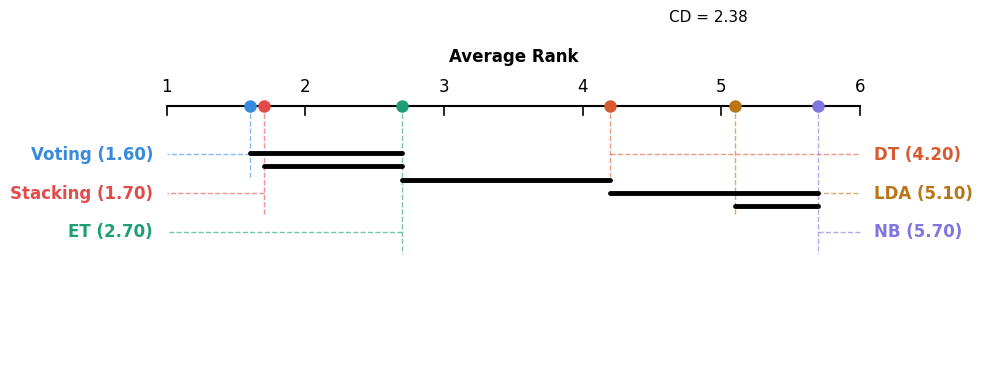

Done. Saved as cd_diagram.png


In [4]:
n_methods = len(methods)
n_metrics = 4

scores = np.zeros((len(datasets), len(models)))

for i, ds in enumerate(datasets):
    for j, model in enumerate(models):
        vals = raw[ds][model]
        scores[i, j] = np.mean(vals)

ranks = np.zeros_like(scores)
for i in range(len(datasets)):
    # higher score = better → negate for ascending rank
    ranks[i] = rankdata(-scores[i])

mean_ranks = ranks.mean(axis=0)
N = len(datasets)
k = len(models)


#Friedman_Test
stat, p_value = friedmanchisquare(*[ranks[:, j] for j in range(k)])

#Nemenyi_Test
q_alpha = 2.850   # Nemenyi, alpha=0.05, k=6
CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))

sorted_idx   = np.argsort(mean_ranks)
sorted_names = [models[i] for i in sorted_idx]
sorted_ranks = mean_ranks[sorted_idx]

sig_pairs = []
for (i, j) in combinations(range(k), 2):
    if abs(sorted_ranks[i] - sorted_ranks[j]) > CD:
        sig_pairs.append((sorted_names[i], sorted_names[j]))

print("\nSignificantly different pairs:")
for p in sig_pairs:
    print(f"  {p[0]} vs {p[1]}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(0.5, k + 0.5)
ax.set_ylim(-2.5, 2.0)
ax.axis("off")

axis_y = 1.2
ax.plot([1, k], [axis_y, axis_y], color="black", lw=1.5)
for r in range(1, k + 1):
    ax.plot([r, r], [axis_y, axis_y - 0.12], color="black", lw=1.2)
    ax.text(r, axis_y + 0.15, str(r), ha="center", va="bottom",
            fontsize=12, color="black")
ax.text((1 + k) / 2, axis_y + 0.55, "Average Rank",
        ha="center", va="bottom", fontsize=12, fontweight="bold")

cd_x_start = k - CD + 0.1
cd_y       = axis_y + 0.95
ax.annotate("", xy=(k + 0.1, cd_y),
            xytext=(cd_x_start, cd_y),
            arrowprops=dict(arrowstyle="-", color="black", lw=1.5))
ax.plot([cd_x_start, cd_x_start], [cd_y - 0.08, cd_y + 0.08],
        color="black", lw=1.5)
ax.plot([k + 0.1, k + 0.1], [cd_y - 0.08, cd_y + 0.08],
        color="black", lw=1.5)
ax.text((cd_x_start + k + 0.1) / 2, cd_y + 0.15,
        f"CD = {CD:.2f}", ha="center", va="bottom", fontsize=11)

colors_map = {
    "ET":       "#1D9E75",
    "DT":       "#D85A30",
    "NB":       "#7F77DD",
    "LDA":      "#BA7517",
    "Voting":   "#378ADD",
    "Stacking": "#E24B4A",
}

# split labels: top half left side, bottom half right side
n_left  = k // 2
n_right = k - n_left

label_y_top    =  0.55
label_y_step   =  0.52
line_drop      = -0.30

for pos, (name, rank) in enumerate(zip(sorted_names, sorted_ranks)):
    color = colors_map[name]
    # dot on axis
    ax.plot(rank, axis_y, "o", color=color, ms=8, zorder=5)

    if pos < n_left:
        # left side — labels go above-left
        ly = label_y_top - pos * label_y_step
        ax.plot([rank, rank], [axis_y, axis_y + line_drop + (ly - axis_y)],
                color=color, lw=1.0, ls="--", alpha=0.6)
        ax.plot([rank, 1.0], [ly, ly], color=color, lw=1.0, ls="--", alpha=0.6)
        ax.text(0.9, ly, f"{name} ({rank:.2f})",
                ha="right", va="center", fontsize=12,
                color=color, fontweight="bold")
    else:
        # right side — labels go above-right
        rpos = pos - n_left
        ly   = label_y_top - rpos * label_y_step
        ax.plot([rank, rank], [axis_y, axis_y + line_drop + (ly - axis_y)],
                color=color, lw=1.0, ls="--", alpha=0.6)
        ax.plot([rank, k + 0.0], [ly, ly], color=color, lw=1.0, ls="--", alpha=0.6)
        ax.text(k + 0.1, ly, f"{name} ({rank:.2f})",
                ha="left", va="center", fontsize=12,
                color=color, fontweight="bold")

clique_y   = axis_y - 0.45
clique_step = 0.18
drawn = []

for i in range(k):
    group = [i]
    for j in range(i + 1, k):
        pair = (sorted_names[i], sorted_names[j])
        pair_r = (sorted_names[j], sorted_names[i])
        if pair not in sig_pairs and pair_r not in sig_pairs:
            group.append(j)
    if len(group) > 1:
        key = tuple(group)
        if key not in drawn:
            drawn.append(key)
            bar_y = clique_y - len(drawn) * clique_step
            x_start = sorted_ranks[group[0]]
            x_end   = sorted_ranks[group[-1]]
            ax.plot([x_start, x_end], [bar_y, bar_y],
                    color="black", lw=3.5, solid_capstyle="round")

sig_str = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.4f}"

plt.tight_layout()
plt.savefig("cd_diagram.png", dpi=300, bbox_inches="tight")
plt.show()
print("Done. Saved as cd_diagram.png")

Pairwise Comparison of Classifiers (Post-hoc Test)

In [5]:
k        = len(models)
N        = len(datasets)

scores = np.zeros((N, k))
for i, ds in enumerate(datasets):
    for j, model in enumerate(models):
        scores[i, j] = np.mean(raw[ds][model])

ranks = np.zeros_like(scores)
for i in range(N):
    ranks[i] = rankdata(-scores[i])

mean_ranks = ranks.mean(axis=0)


stat, p_value = friedmanchisquare(*[ranks[:, j] for j in range(k)])

from scipy.stats import norm

se = np.sqrt(k * (k + 1) / (6 * N))

p_matrix = np.ones((k, k))
z_matrix = np.zeros((k, k))

for i, j in combinations(range(k), 2):
    diff = abs(mean_ranks[i] - mean_ranks[j])
    z    = diff / se
    p    = 2 * (1 - norm.cdf(z / np.sqrt(2)))
    p    = min(p, 1.0)
    p_matrix[i, j] = p
    p_matrix[j, i] = p
    z_matrix[i, j] = z
    z_matrix[j, i] = z

print("Mean Ranks:")
for m, r in zip(models, mean_ranks):
    print(f"  {m:<10} {r:.4f}")
print(f"\nFriedman: chi2={stat:.4f}, p={p_value:.6f}\n")

def fmt_p(p, i, j):
    """Format p-value cell with significance markers."""
    if i == j:
        return r"—"
    if p < 0.001:
        val = r"\textbf{<0.001}$^{***}$"
    elif p < 0.01:
        val = r"\textbf{" + f"{p:.3f}" + r"}$^{**}$"
    elif p < 0.05:
        val = r"\textbf{" + f"{p:.3f}" + r"}$^{*}$"
    else:
        val = f"{p:.3f}"
    return val

latex = []
latex.append(r"\begin{table}[!t]")
latex.append(r"\caption{Nemenyi Post-Hoc Test p-Values for Pairwise Classifier Comparisons (Friedman test: $\chi^2$ = " + f"{stat:.3f}" + r", $p < 0.001$)}")
latex.append(r"\label{tab:nemenyi}")
latex.append(r"\centering")
latex.append(r"\renewcommand{\arraystretch}{1.2}")
latex.append(r"\begin{adjustbox}{max width=\columnwidth}")

col_fmt = "l" + "c" * k
latex.append(r"\begin{tabular}{" + col_fmt + "}")
latex.append(r"\toprule")

# Header row
header = r"\textbf{Classifier} & " + " & ".join(
    [r"\textbf{" + m + "}" for m in models]
) + r" \\"
latex.append(header)

# Mean rank sub-header
rank_row = r"\textbf{Mean Rank} & " + " & ".join(
    [f"{mean_ranks[j]:.2f}" for j in range(k)]
) + r" \\"
latex.append(r"\midrule")
latex.append(rank_row)
latex.append(r"\midrule")

# p-value rows
for i, m in enumerate(models):
    row_cells = [r"\textbf{" + m + "}"]
    for j in range(k):
        row_cells.append(fmt_p(p_matrix[i, j], i, j))
    latex.append(" & ".join(row_cells) + r" \\")

latex.append(r"\bottomrule")
latex.append(r"\multicolumn{" + str(k + 1) + r"}{l}{\footnotesize $^{*}p<0.05$, $^{**}p<0.01$, $^{***}p<0.001$. Bold = statistically significant. `—' = self-comparison.}")
latex.append(r"\end{tabular}")
latex.append(r"\end{adjustbox}")
latex.append(r"\end{table}")

latex_str = "\n".join(latex)
print("=" * 60)
print("LaTeX Table:")
print("=" * 60)
print(latex_str)

# Save to file
with open("nemenyi_table.tex", "w") as f:
    f.write(latex_str)

print("\nSaved as nemenyi_table.tex")

Mean Ranks:
  ET         2.7000
  DT         4.2000
  NB         5.7000
  LDA        5.1000
  Voting     1.6000
  Stacking   1.7000

Friedman: chi2=43.9429, p=0.000000

LaTeX Table:
\begin{table}[!t]
\caption{Nemenyi Post-Hoc Test p-Values for Pairwise Classifier Comparisons (Friedman test: $\chi^2$ = 43.943, $p < 0.001$)}
\label{tab:nemenyi}
\centering
\renewcommand{\arraystretch}{1.2}
\begin{adjustbox}{max width=\columnwidth}
\begin{tabular}{lcccccc}
\toprule
\textbf{Classifier} & \textbf{ET} & \textbf{DT} & \textbf{NB} & \textbf{LDA} & \textbf{Voting} & \textbf{Stacking} \\
\midrule
\textbf{Mean Rank} & 2.70 & 4.20 & 5.70 & 5.10 & 1.60 & 1.70 \\
\midrule
\textbf{ET} & — & 0.205 & \textbf{0.011}$^{*}$ & \textbf{0.043}$^{*}$ & 0.353 & 0.398 \\
\textbf{DT} & 0.205 & — & 0.205 & 0.447 & \textbf{0.028}$^{*}$ & \textbf{0.035}$^{*}$ \\
\textbf{NB} & \textbf{0.011}$^{*}$ & 0.205 & — & 0.612 & \textbf{<0.001}$^{***}$ & \textbf{<0.001}$^{***}$ \\
\textbf{LDA} & \textbf{0.043}$^{*}$ & 0.447 & 

Heatmap Graph (Baseline Vs. CrFB-Net)

In [7]:
baseline = {
    "D1":  {"ET": [0.8080,0.8071,0.7963,0.8793], "DT": [0.7480,0.7463,0.7310,0.7467],
             "NB": [0.7522,0.7519,0.7408,0.8234], "LDA": [0.7719,0.7641,0.7419,0.8638],
             "Voting": [0.8244,0.8243,0.8161,0.8961], "Stacking": [0.8161,0.8165,0.8095,0.8860]},
    "D2":  {"ET": [0.7398,0.6817,0.5977,0.8128], "DT": [0.7007,0.6681,0.5774,0.6740],
             "NB": [0.7454,0.7070,0.6267,0.8084], "LDA": [0.7695,0.7267,0.6536,0.8333],
             "Voting": [0.7416,0.6989,0.6171,0.8125], "Stacking": [0.7193,0.6298,0.5354,0.7556]},
    "D3":  {"ET": [0.8642,0.1103,0.0233,0.5253], "DT": [0.7609,0.3891,0.1645,0.5139],
             "NB": [0.8579,0.1283,0.0301,0.5480], "LDA": [0.8680,0.0334,0.0022,0.5544],
             "Voting": [0.8676,0.0578,0.0066,0.5516], "Stacking": [0.8646,0.0333,0.0022,0.5279]},
    "D4":  {"ET": [0.5873,0.4209,0.2189,0.5374], "DT": [0.5103,0.4195,0.2162,0.5142],
             "NB": [0.6450,0.4344,0.2111,0.5879], "LDA": [0.6943,0.4156,0.1925,0.6241],
             "Voting": [0.6657,0.4183,0.2065,0.5927], "Stacking": [0.6931,0.4130,0.1893,0.5940]},
    "D5":  {"ET": [0.8498,0.2377,0.1033,0.6846], "DT": [0.7579,0.4729,0.2488,0.5552],
             "NB": [0.8208,0.4174,0.2400,0.7232], "LDA": [0.8514,0.3348,0.1888,0.7348],
             "Voting": [0.8467,0.2577,0.1176,0.6985], "Stacking": [0.8483,0.1898,0.0676,0.6515]},
    "D6":  {"ET": [0.9513,0.2810,0.1439,0.7395], "DT": [0.9165,0.5042,0.2487,0.6095],
             "NB": [0.9437,0.4455,0.2706,0.7359], "LDA": [0.9502,0.4096,0.2600,0.7447],
             "Voting": [0.9535,0.3538,0.2180,0.7873], "Stacking": [0.9411,0.4140,0.2344,0.7431]},
    "D7":  {"ET": [0.8183,0.7168,0.6294,0.8488], "DT": [0.7612,0.6931,0.5713,0.7060],
             "NB": [0.5072,0.5680,0.5056,0.7569], "LDA": [0.7744,0.5661,0.4543,0.7896],
             "Voting": [0.8269,0.7110,0.6319,0.8729], "Stacking": [0.8218,0.7187,0.6338,0.8586]},
    "D8":  {"ET": [0.7076,0.5301,0.8077,0.7440], "DT": [0.6199,0.5258,0.7280,0.5504],
             "NB": [0.5789,0.6386,0.5955,0.7203], "LDA": [0.7076,0.2433,0.8252,0.7175],
             "Voting": [0.7076,0.5569,0.8047,0.7355], "Stacking": [0.6550,0.4933,0.7668,0.6913]},
    "D9":  {"ET": [0.9108,0.8520,0.7914,0.9622], "DT": [0.9013,0.8555,0.7789,0.8589],
             "NB": [0.8035,0.5054,0.3765,0.7686], "LDA": [0.8646,0.8053,0.7011,0.9329],
             "Voting": [0.9259,0.8736,0.8260,0.9729], "Stacking": [0.9233,0.8558,0.8137,0.9709]},
    "D10": {"ET": [0.8916,0.7177,0.9379,0.9003], "DT": [0.8795,0.7124,0.9306,0.7380],
             "NB": [0.8795,0.7638,0.9296,0.8775], "LDA": [0.9036,0.7752,0.9444,0.9192],
             "Voting": [0.9157,0.7809,0.9517,0.9331], "Stacking": [0.8795,0.6552,0.9315,0.8586]},
}


proposed_raw = {
    "D1": {
        "ET":       [0.8507,0.9125,0.8504,0.9878, 0.8070,0.8858,0.8063,0.9781, 0.9117,0.9355,0.8963,0.9937, 0.8130,0.8895,0.8123,0.9791],
        "DT":       [0.8052,0.8847,0.8048,0.8887, 0.7401,0.8441,0.7402,0.8515, 0.8983,0.9314,0.8809,0.9329, 0.7461,0.8480,0.7461,0.8549],
        "NB":       [0.6979,0.8171,0.6912,0.9521, 0.7158,0.8287,0.7115,0.9535, 0.8772,0.9116,0.8538,0.9825, 0.7250,0.8346,0.7223,0.9559],
        "LDA":      [0.7331,0.8397,0.7291,0.9619, 0.7425,0.8457,0.7402,0.9622, 0.8887,0.9140,0.8553,0.9902, 0.7556,0.8539,0.7536,0.9649],
        "Voting":   [0.8617,0.9191,0.8614,0.9876, 0.8191,0.8932,0.8185,0.9812, 0.9367,0.9511,0.9256,0.9957, 0.8236,0.8960,0.8229,0.9821],
        "Stacking": [0.8514,0.9129,0.8515,0.9877, 0.8031,0.8835,0.8028,0.9782, 0.9136,0.9416,0.9022,0.9875, 0.8063,0.8854,0.8059,0.9793],
    },
    "D2": {
        "ET":       [0.8415,0.9113,0.8398,0.9841, 0.8415,0.9113,0.8364,0.9833, 0.9541,0.9663,0.9447,0.9986, 0.8415,0.9113,0.8329,0.9828],
        "DT":       [0.8228,0.9004,0.8197,0.9040, 0.7762,0.8728,0.7752,0.8788, 0.9187,0.9278,0.8749,0.9299, 0.7716,0.8700,0.7652,0.8763],
        "NB":       [0.7319,0.8459,0.7230,0.9667, 0.7483,0.8559,0.7440,0.9724, 0.8163,0.8703,0.7416,0.9855, 0.7436,0.8531,0.7334,0.9682],
        "LDA":      [0.6107,0.7687,0.6028,0.9499, 0.6643,0.8036,0.6577,0.9557, 0.7385,0.8325,0.7197,0.9749, 0.6340,0.7840,0.6271,0.9480],
        "Voting":   [0.8695,0.9274,0.8657,0.9876, 0.8601,0.9220,0.8559,0.9851, 0.9753,0.9827,0.9720,0.9989, 0.8462,0.9140,0.8382,0.9846],
        "Stacking": [0.8298,0.9045,0.8287,0.9815, 0.8462,0.9140,0.8422,0.9770, 0.9611,0.9696,0.9495,0.9956, 0.8322,0.9058,0.8230,0.9808],
    },
    "D3": {
        "ET":       [0.9257,0.9581,0.9248,0.9895, 0.8640,0.9225,0.8636,0.9749, 0.9586,0.9740,0.9547,0.9989, 0.8679,0.9247,0.8676,0.9753],
        "DT":       [0.8994,0.9430,0.8976,0.9608, 0.8098,0.8904,0.8097,0.9019, 0.8821,0.9286,0.8735,0.9304, 0.8256,0.8998,0.8255,0.9112],
        "NB":       [0.5328,0.7107,0.5329,0.9343, 0.5403,0.7160,0.5351,0.9345, 0.5931,0.7326,0.5620,0.9396, 0.4924,0.6816,0.4710,0.9207],
        "LDA":      [0.5584,0.7287,0.5554,0.9469, 0.5531,0.7250,0.5504,0.9465, 0.6282,0.7526,0.5856,0.9539, 0.5539,0.7256,0.5516,0.9447],
        "Voting":   [0.9093,0.9487,0.9079,0.9961, 0.8838,0.9340,0.8836,0.9934, 0.9567,0.9734,0.9540,0.9990, 0.8953,0.9407,0.8952,0.9938],
        "Stacking": [0.9519,0.9731,0.9518,0.9968, 0.8870,0.9359,0.8871,0.9936, 0.9676,0.9807,0.9651,0.9993, 0.8944,0.9401,0.8945,0.9940],
    },
    "D4": {
        "ET":       [0.8620,0.9231,0.8600,0.9885, 0.8431,0.9094,0.8357,0.9849, 0.9326,0.9462,0.9093,0.9965, 0.8246,0.9014,0.8204,0.9831],
        "DT":       [0.8402,0.9105,0.8401,0.9151, 0.8089,0.8895,0.8043,0.8951, 0.9222,0.9420,0.8911,0.9433, 0.7856,0.8784,0.7857,0.8847],
        "NB":       [0.4378,0.6460,0.4325,0.9171, 0.4215,0.6309,0.4074,0.9177, 0.4477,0.6454,0.4147,0.9171, 0.3960,0.6133,0.3781,0.9083],
        "LDA":      [0.6007,0.7620,0.5950,0.9538, 0.6285,0.7787,0.6191,0.9563, 0.7110,0.8033,0.6618,0.9691, 0.5879,0.7535,0.5815,0.9501],
        "Voting":   [0.8837,0.9355,0.8801,0.9932, 0.8667,0.9227,0.8567,0.9917, 0.9557,0.9609,0.9340,0.9980, 0.8500,0.9162,0.8427,0.9902],
        "Stacking": [0.8828,0.9350,0.8805,0.9934, 0.8687,0.9242,0.8605,0.9912, 0.9514,0.9609,0.9304,0.9976, 0.8507,0.9166,0.8455,0.9899],
    },
    "D5": {
        "ET":       [0.9807,0.9889,0.9805,0.9995, 0.8388,0.9052,0.8383,0.9861, 0.8790,0.8682,0.7811,0.9896, 0.8760,0.9276,0.8757,0.9899],
        "DT":       [0.9249,0.9565,0.9229,0.9571, 0.7528,0.8522,0.7521,0.8587, 0.8346,0.8575,0.7559,0.8647, 0.7929,0.8772,0.7916,0.8816],
        "NB":       [0.3268,0.5435,0.2669,0.7911, 0.3542,0.5670,0.2974,0.8135, 0.4979,0.5788,0.3552,0.8665, 0.3712,0.5812,0.3307,0.8145],
        "LDA":      [0.5358,0.7073,0.5353,0.9308, 0.6150,0.7623,0.6113,0.9444, 0.6878,0.7409,0.5768,0.9466, 0.6417,0.7803,0.6387,0.9499],
        "Voting":   [0.9740,0.9851,0.9737,0.9994, 0.8560,0.9156,0.8557,0.9879, 0.9052,0.8966,0.8400,0.9940, 0.8852,0.9331,0.8849,0.9907],
        "Stacking": [0.9843,0.9910,0.9843,0.9995, 0.8496,0.9118,0.8497,0.9868, 0.8881,0.9000,0.8293,0.9888, 0.8831,0.9319,0.8835,0.9903],
    },
    "D6": {
        "ET":       [0.9637,0.9772,0.9636,0.9967, 0.9113,0.9440,0.9111,0.9893, 0.9368,0.9457,0.9174,0.9947, 0.9102,0.9433,0.9099,0.9891],
        "DT":       [0.9184,0.9485,0.9175,0.9490, 0.8258,0.8887,0.8255,0.8911, 0.8796,0.9102,0.8549,0.9121, 0.8386,0.8971,0.8382,0.8991],
        "NB":       [0.6231,0.7511,0.5967,0.8881, 0.6580,0.7756,0.6421,0.8963, 0.7277,0.8262,0.7068,0.9333, 0.6594,0.7766,0.6368,0.8991],
        "LDA":      [0.6933,0.8000,0.6908,0.9152, 0.7007,0.8051,0.7002,0.9236, 0.8092,0.8491,0.7568,0.9487, 0.7193,0.8177,0.7181,0.9277],
        "Voting":   [0.9519,0.9698,0.9519,0.9982, 0.9173,0.9478,0.9172,0.9922, 0.9396,0.9488,0.9222,0.9956, 0.9255,0.9530,0.9255,0.9923],
        "Stacking": [0.9857,0.9911,0.9858,0.9980, 0.9216,0.9505,0.9213,0.9924, 0.9492,0.9621,0.9375,0.9960, 0.9323,0.9573,0.9324,0.9916],
    },
    "D7": {
        "ET":       [0.9648,0.9797,0.9644,0.9984, 0.9402,0.9655,0.9393,0.9963, 0.9480,0.9681,0.9446,0.9968, 0.9511,0.9718,0.9509,0.9963],
        "DT":       [0.9716,0.9837,0.9715,0.9838, 0.9169,0.9518,0.9168,0.9525, 0.9300,0.9582,0.9281,0.9587, 0.9417,0.9664,0.9417,0.9667],
        "NB":       [0.6535,0.7881,0.6484,0.9505, 0.7409,0.8447,0.7405,0.9667, 0.7694,0.8590,0.7638,0.9709, 0.7332,0.8398,0.7293,0.9613],
        "LDA":      [0.4543,0.6472,0.4531,0.8553, 0.4768,0.6642,0.4720,0.8651, 0.4958,0.6691,0.4762,0.8711, 0.6030,0.7542,0.5886,0.9148],
        "Voting":   [0.9867,0.9924,0.9867,0.9999, 0.9558,0.9745,0.9556,0.9985, 0.9657,0.9795,0.9649,0.9989, 0.9758,0.9861,0.9758,0.9985],
        "Stacking": [0.9955,0.9974,0.9955,0.9999, 0.9689,0.9821,0.9689,0.9991, 0.9708,0.9829,0.9699,0.9986, 0.9773,0.9870,0.9773,0.9986],
    },
    "D8": {
        "ET":       [0.9776,0.9865,0.9771,0.9996, 0.8860,0.9304,0.8779,0.9864, 0.9570,0.9369,0.8942,0.9956, 0.9178,0.9500,0.9102,0.9929],
        "DT":       [0.9514,0.9706,0.9485,0.9708, 0.8617,0.9153,0.8609,0.9169, 0.9332,0.9318,0.8831,0.9334, 0.8766,0.9247,0.8729,0.9260],
        "NB":       [0.7215,0.8251,0.6998,0.9266, 0.7589,0.8496,0.7419,0.9234, 0.8854,0.8872,0.8129,0.9748, 0.7645,0.8534,0.7429,0.9353],
        "LDA":      [0.4766,0.6535,0.4809,0.8221, 0.4673,0.6462,0.4677,0.8220, 0.5179,0.6533,0.4841,0.8462, 0.5327,0.6950,0.5358,0.8360],
        "Voting":   [0.9607,0.9763,0.9589,0.9997, 0.9084,0.9442,0.9053,0.9891, 0.9761,0.9590,0.9405,0.9966, 0.9308,0.9580,0.9269,0.9949],
        "Stacking": [0.9925,0.9955,0.9925,1.0000, 0.8953,0.9362,0.8951,0.9748, 0.9690,0.9637,0.9374,0.9966, 0.9234,0.9535,0.9221,0.9905],
    },
    "D9": {
        "ET":       [0.9797,0.9865,0.9795,0.9945, 0.9527,0.9683,0.9529,0.9897, 0.9697,0.9747,0.9674,0.9991, 0.9595,0.9729,0.9595,0.9907],
        "DT":       [0.9459,0.9638,0.9451,0.9640, 0.9459,0.9638,0.9459,0.9640, 0.9293,0.9442,0.9148,0.9448, 0.9257,0.9501,0.9264,0.9505],
        "NB":       [0.8243,0.8809,0.8184,0.9456, 0.9122,0.9410,0.9119,0.9878, 0.9697,0.9803,0.9663,0.9950, 0.9257,0.9501,0.9259,0.9937],
        "LDA":      [0.9189,0.9456,0.9196,0.9910, 0.9257,0.9501,0.9257,0.9887, 0.9394,0.9604,0.9362,0.9848, 0.9189,0.9456,0.9185,0.9920],
        "Voting":   [0.9797,0.9865,0.9795,0.9974, 0.9595,0.9729,0.9595,0.9952, 0.9697,0.9747,0.9674,0.9997, 0.9595,0.9729,0.9595,0.9958],
        "Stacking": [0.9797,0.9865,0.9796,0.9928, 0.9459,0.9638,0.9458,0.9844, 0.9798,0.9831,0.9780,0.9801, 0.9257,0.9501,0.9258,0.9687],
    },
    "D10": {
        "ET":       [0.9756,0.9865,0.9756,0.9999, 0.9292,0.9606,0.9290,0.9982, 0.9672,0.9376,0.9198,0.9974, 0.9394,0.9663,0.9392,0.9988],
        "DT":       [0.9704,0.9836,0.9703,0.9837, 0.9187,0.9546,0.9187,0.9553, 0.9667,0.9521,0.9229,0.9531, 0.9336,0.9630,0.9335,0.9635],
        "NB":       [0.3922,0.6069,0.3774,0.8254, 0.3818,0.5985,0.3571,0.8178, 0.5539,0.5864,0.3695,0.9125, 0.3669,0.5862,0.3508,0.8211],
        "LDA":      [0.8331,0.9051,0.8203,0.9936, 0.5250,0.7072,0.5019,0.9054, 0.9461,0.8947,0.8568,0.9964, 0.8352,0.9064,0.8230,0.9944],
        "Voting":   [0.9697,0.9832,0.9695,0.9997, 0.9437,0.9687,0.9435,0.9987, 0.9765,0.9530,0.9411,0.9992, 0.9493,0.9718,0.9491,0.9991],
        "Stacking": [0.9883,0.9936,0.9883,0.9998, 0.9341,0.9633,0.9338,0.9983, 0.9728,0.9553,0.9337,0.9982, 0.9516,0.9731,0.9516,0.9990],
    },
}


datasets  = ["D1","D2","D3","D4","D5","D6","D7","D8","D9","D10"]
models    = ["ET","DT","NB","LDA","Voting","Stacking"]
metrics   = ["Accuracy","G-Mean","F1 Score","AUROC"]
n_metrics = 4


def get_proposed_avg(ds, model):
    vals = proposed_raw[ds][model]  # 16 values
    return [
        np.mean([vals[0],  vals[4],  vals[8],  vals[12]]),   # Accuracy
        np.mean([vals[1],  vals[5],  vals[9],  vals[13]]),   # G-Mean
        np.mean([vals[2],  vals[6],  vals[10], vals[14]]),   # F1
        np.mean([vals[3],  vals[7],  vals[11], vals[15]]),   # AUROC
    ]


row_labels = []
delta_matrix = []

for ds in datasets:
    for model in models:
        prop = get_proposed_avg(ds, model)
        base = baseline[ds][model]
        delta = [p - b for p, b in zip(prop, base)]
        delta_matrix.append(delta)
        row_labels.append(f"{ds}-{model}")

delta_matrix = np.array(delta_matrix)


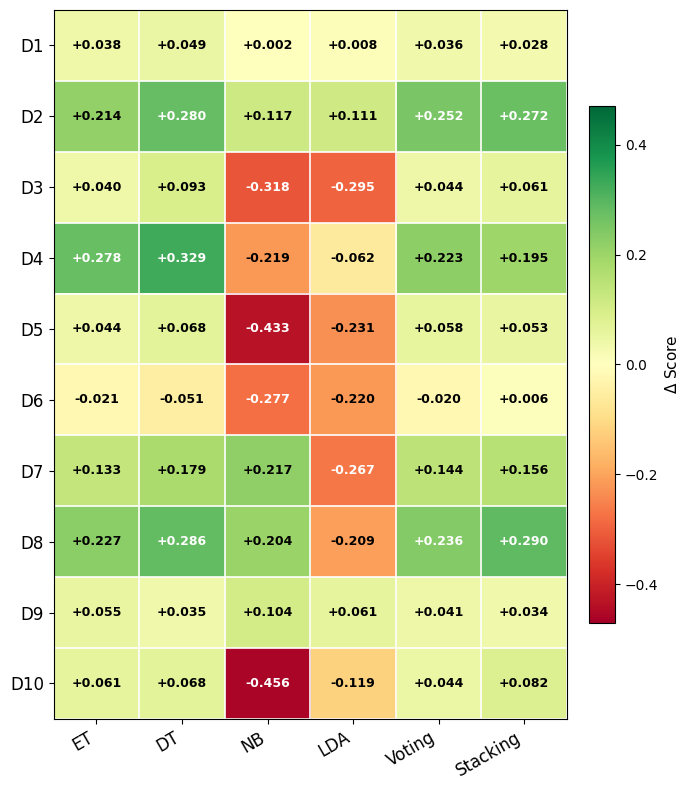

Saved: delta_heatmap_Accuracy.png


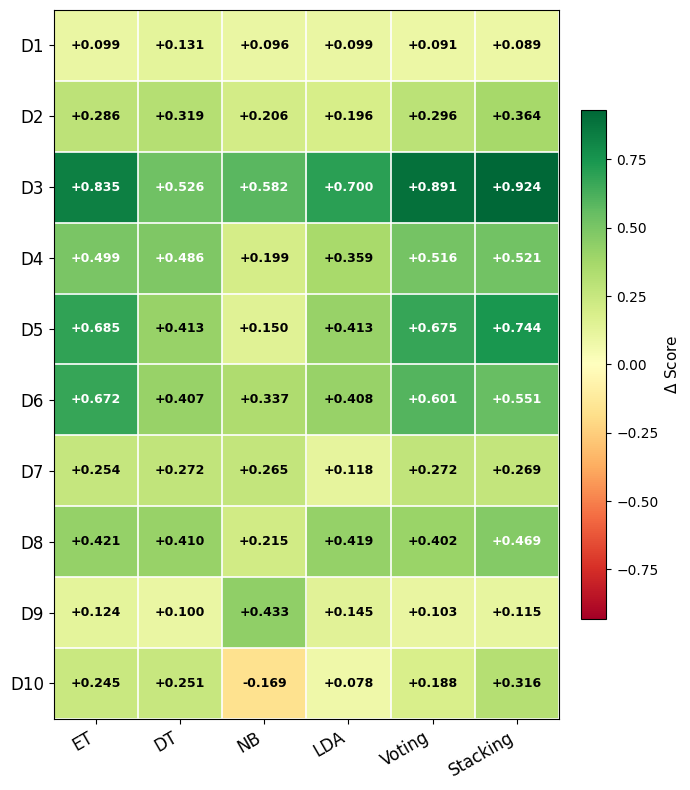

Saved: delta_heatmap_G-Mean.png


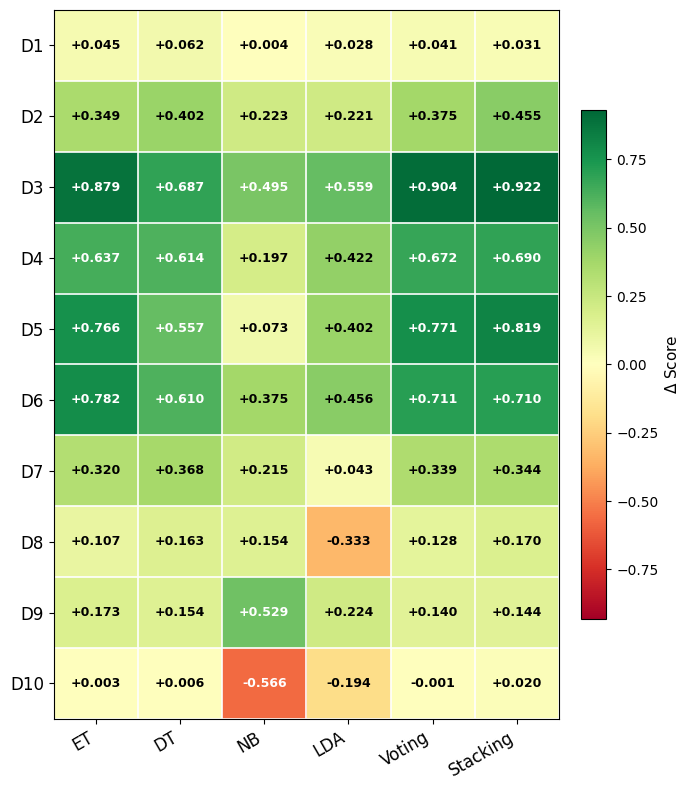

Saved: delta_heatmap_F1_Score.png


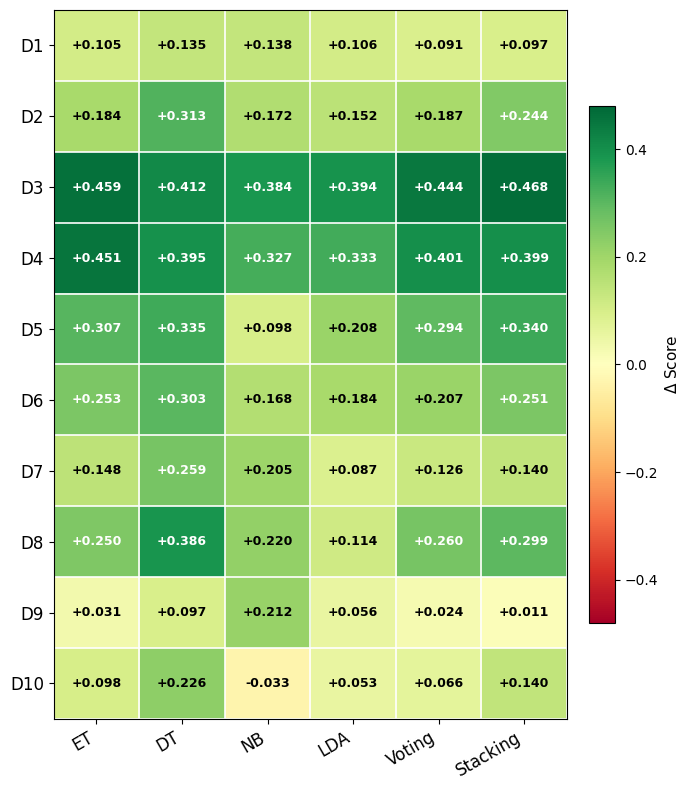

Saved: delta_heatmap_AUROC.png


In [8]:
cmap = plt.cm.RdYlGn

for m_col, metric in enumerate(metrics):

    fig, ax = plt.subplots(figsize=(7, 8))

    # build (10, 6)
    grid = np.zeros((len(datasets), len(models)))
    for i, ds in enumerate(datasets):
        for j, model in enumerate(models):
            row_idx = i * len(models) + j
            grid[i, j] = delta_matrix[row_idx, m_col]

    abs_max = np.max(np.abs(grid))
    vmax    = round(abs_max + 0.01, 2)
    vmin    = -vmax

    im = ax.imshow(grid, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")

    for i in range(len(datasets)):
        for j in range(len(models)):
            val      = grid[i, j]
            norm_val = (val - vmin) / (vmax - vmin)
            txt_col  = "white" if (norm_val < 0.25 or norm_val > 0.75) else "black"
            sign     = "+" if val >= 0 else ""
            ax.text(j, i, f"{sign}{val:.3f}",
                    ha="center", va="center",
                    fontsize=9, color=txt_col, fontweight="bold")

    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, fontsize=12, rotation=30, ha="right")
    ax.set_yticks(range(len(datasets)))
    ax.set_yticklabels(datasets, fontsize=12)

    # grid lines
    ax.set_xticks(np.arange(-0.5, len(models), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(datasets), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.tick_params(labelsize=10)
    cb.set_label(r"$\Delta$ Score", fontsize=11)

    plt.tight_layout()
    fname = f"delta_heatmap_{metric.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")